# RA PARTE 2
## CNN como extractor de características + Boosting como clasificador

___________

## Introducción al problema

La empresa VisualQuality S.A. quiere automatizar la inspección visual de imágenes
de productos (tejidos, prendas, componentes…). Actualmente, el proceso es manual y
lento. Se quiere comparar:

● Un modelo profundo (CNN) capaz de aprender directamente de imágenes

● vs. un modelo tabular avanzado (boosting) entrenado con features
profundas.

Esta comparación es habitual en pipelines reales de ML:

" *Una CNN aprende
representaciones profundas; un modelo de boosting usa esas representaciones de
forma tabular.*”

**Tu misión es construir ambos modelos y compararlos de forma rigurosa.**

**Dataset:**“Fruits and Vegetables Image Dataset (Fruits360)” que deberás
descargarlo de Kaggle: https://www.kaggle.com/datasets/moltean/fruits  - Imágenes del dataser 100x100 pixeles

Preprocesamiento de imágenes **64×64 px**

Usaremos **3 clases** : Manzana, plátano y cereza


## Sección 0: Setup, instalación y reproducibilidad

In [ ]:
#Montamos Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Ejecuta esta celda solo la primera vez, o si estas en Google Colab
SEED = 42
BATCH_SIZE = 32
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Comprobamos versiones
print(f"XGBoost:    {xgb.__version__}")
print("Setup completado")

XGBoost:    3.2.0
Setup completado


## Sección 1: Carga y exploración del dataset fruits-360

**Fruits-360 Dataset properties **:

Total number of images: 182945.

Training set size: 137221 images.

Test set size: 45724 images.

Number of classes: 260 (fruits, vegetables, nuts and seeds).

Image size: 100x100 pixels.

**Las 260 clases de fruits-360:** usaremos 3 : banana, apple y Cherry.

In [ ]:
#Descarga del dataset de https://www.kaggle.com/datasets/moltean/fruits
import kagglehub
# =============================================================================
# PASO 1. Descargamos el dataset
# =============================================================================
!pip install kaggle
from google.colab import files
files.upload()  # aquí subes tu kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d moltean/fruits

#El split ya está hecho por los autores del dataset.
!unzip fruits.zip -d data #descarga de


Saving kaggle.json to kaggle (1).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
fruits.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fruits.zip
replace data/fruits-360_100x100/fruits-360/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: o
error:  invalid response [o]
replace data/fruits-360_100x100/fruits-360/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/fruits-360_100x100/fruits-360/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/fruits-360_100x100/fruits-360/Test/Almonds 1/r0_103_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace data/fruits-360_100x100/fruits-360/Test/Almonds 1/r0_107_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: [n]o
error:  invalid response [[n]o]
replace data/fruits-360_100x100/fruits-360/Test/Almonds 1/r0_107_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
None
[N]one
[N]
N

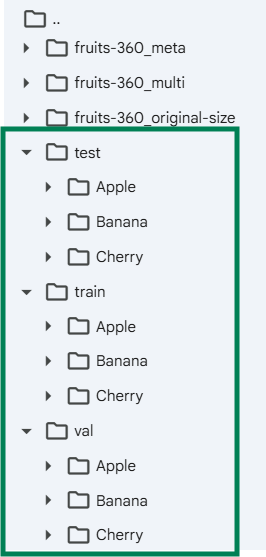

In [ ]:
import os, shutil, glob

# Carpetas originales del dataset Fruits360
train_src = "data/fruits-360_original-size/fruits-360-original-size/Training"
test_src  = "data/fruits-360_original-size/fruits-360-original-size/Test"

# Clases que queremos agrupar
mapping = {
    "Apple":  ["Apple*"],
    "Banana": ["Banana*"],
    "Cherry": ["Cherry*"]
}

# Crear carpetas destino
for split in ["train", "test"]:
    for cls in mapping.keys():
        os.makedirs(f"data/{split}/{cls}", exist_ok=True)

# Función para copiar imágenes agrupando variantes
def copy_grouped(src_root, dst_root):
    for cls, patterns in mapping.items():
        for pattern in patterns:
            for folder in glob.glob(f"{src_root}/{pattern}"):
                for img in glob.glob(folder + "/*.jpg"):
                    shutil.copy(img, f"{dst_root}/{cls}/")

# Copiar train y test
copy_grouped(train_src, "data/train")
copy_grouped(test_src, "data/test")

In [ ]:
#Creamos validación (20%) automaticamente
from sklearn.model_selection import train_test_split
import os, shutil

# Remove existing validation directory to ensure a clean split
if os.path.exists("data/val"):
    shutil.rmtree("data/val")

os.makedirs("data/val", exist_ok=True)
for cls in mapping.keys():
    os.makedirs(f"data/val/{cls}", exist_ok=True)

for cls in mapping.keys():
    imgs = glob.glob(f"data/train/{cls}/*.jpg")
    train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

    for img in val_imgs:
        shutil.move(img, f"data/val/{cls}/")

In [ ]:
#Redimensionar las imégenes a 64x64
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as T

#Redimensionar las imágenes a 64x64
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])

train_ds = ImageFolder("data/train", transform=transform)
val_ds   = ImageFolder("data/val", transform=transform)
test_ds  = ImageFolder("data/test", transform=transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)
test_dl  = DataLoader(test_ds, batch_size=32)

In [ ]:
#CNN resnet18
import torchvision.transforms as T
from torchvision.models import resnet18
import torch.nn as nn
import torch
from torch import cuda

device = "cuda" if torch.cuda.is_available() else "cpu"

model_cnn = resnet18(weights="IMAGENET1K_V1")
model_cnn.fc = nn.Linear(512, 3)#3 son clases
model_cnn = model_cnn.to(device)

In [ ]:
#Definimos loss,optimizador y funcion de evaluación
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-4)


In [ ]:
#Función para evaluar accuracy:
def accuracy(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


In [ ]:
#entranamiento completo con validación por época
epochs = 10

for epoch in range(epochs):
    model_cnn.train()
    running_loss = 0

    for x, y in train_dl:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model_cnn(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    val_acc = accuracy(model_cnn, val_dl)
    print(f"Época {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")


Época 1/10 | Loss: 3.7276 | Val Acc: 0.9961
Época 2/10 | Loss: 0.0436 | Val Acc: 1.0000
Época 3/10 | Loss: 0.0356 | Val Acc: 1.0000
Época 4/10 | Loss: 0.0187 | Val Acc: 1.0000
Época 5/10 | Loss: 0.0212 | Val Acc: 1.0000
Época 6/10 | Loss: 0.0064 | Val Acc: 1.0000
Época 7/10 | Loss: 0.0122 | Val Acc: 1.0000
Época 8/10 | Loss: 0.0106 | Val Acc: 1.0000
Época 9/10 | Loss: 0.0088 | Val Acc: 1.0000
Época 10/10 | Loss: 0.0084 | Val Acc: 1.0000


In [ ]:
#Evaluación final en test
test_acc = accuracy(model_cnn, test_dl)
print("Accuracy en test:", test_acc)


Accuracy en test: 1.0


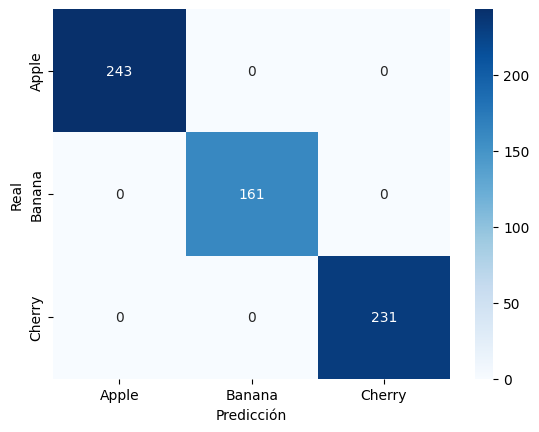

In [ ]:
#Matriz de confusión para CNN resnet18
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_cnn.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        preds = model_cnn(x).argmax(1).cpu()
        y_pred.extend(preds.numpy())
        y_true.extend(y.numpy())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [ ]:
#Modelo 2 — Boosting con features profundas
#Pasar imágenes por una CNN preentrenada sin la última capa
#Extraer embeddings (p. ej. vector de 512 dimensiones)
#Entrenar un XGBoost / LightGBM / CatBoost sobre esos vectores

from torchvision.models import resnet18
import torch.nn as nn
import xgboost as xgb


cnn = resnet18(weights="IMAGENET1K_V1")
feature_extractor = nn.Sequential(*list(cnn.children())[:-1])  # sin la FC

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

In [ ]:
#Estractor de features
from torchvision.models import resnet18
import torch.nn as nn
import xgboost as xgb
import torch


cnn = resnet18(weights="IMAGENET1K_V1")
feature_extractor = nn.Sequential(*list(cnn.children())[:-1])  # sin la FC

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)
#Ejecutamos con GPU y lo ponemos en modo evaluación
device = "cuda" if torch.cuda.is_available() else "cpu"
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
import numpy as np
#Funcion para extraer embedding
#Cada imagen pasará por la ResNet sin la capa final → produce un vector de 512 dimensiones.
def extract_embeddings(dataloader):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            feats = feature_extractor(x)          # shape: (B, 512, 1, 1)
            feats = feats.squeeze()               # shape: (B, 512)
            all_features.append(feats.cpu().numpy())
            all_labels.append(y.numpy())

    X = np.vstack(all_features)
    y = np.hstack(all_labels)
    return X, y


In [ ]:
#Extraer embedding
X_train, y_train = extract_embeddings(train_dl)
X_val,   y_val   = extract_embeddings(val_dl)
X_test,  y_test  = extract_embeddings(test_dl)

X_train.shape, X_val.shape, X_test.shape


((1021, 512), (256, 512), (635, 512))

In [ ]:
#Entrenar con XGBoost sobre embeddings
model_xgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Evaluación en test
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy XGBoost (features profundas):", acc)


Accuracy XGBoost (features profundas): 0.9968503937007874


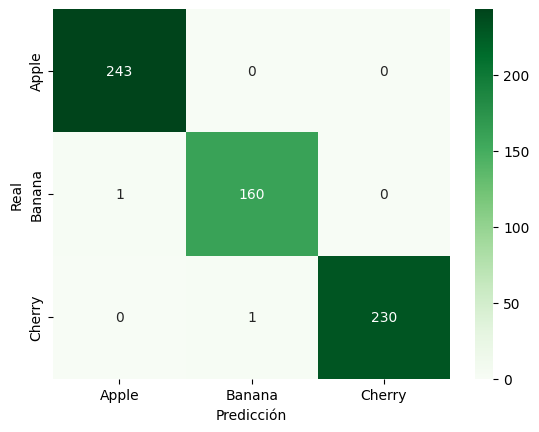

In [ ]:
#Matriz de confusión para XGBoost
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True,fmt="d", cmap="Greens",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


# Tabla comparativa
____________


|Aspecto | CNN (ResNet‑18 end‑to‑end) | XGBoost con embeddings profundos |
|---|---------|-----------|
| Tipo de modelo | Red neuronal convolucional entrenada directamente sobre imágenes |Modelo tabular (boosting) entrenado sobre vectores de 512 dimensiones |
| Fuente de información | Píxeles 64×64 (aprendizaje directo) | Embeddings extraídos por ResNet‑18 (representaciones profundas) |
| Accuracy en test | 1.00 |0.997 |
| Matriz de confusión | Perfecta (0 errores) | Casi perfecta (1–2 errores como máximo) |
| Tiempo de entrenamiento | Alto (entrenamiento por épocas en GPU). Minutos | Muy bajo (entrena en segundos) |
| Capacidad de generalización | Muy alta | Alta, pero limitada por la calidad del embedding |
|Interpretabilidad | Baja | TMedia (importancia de features, árboles) |
| Dependencia del dataset | Aprende patrones visuales complejos | Depende totalmente de la calidad del extractor |

____________

# CONCLUSIONES

**1. ¿Qué modelo tiene mejor rendimiento?**

El modelo CNN end‑to‑end obtiene el mejor rendimiento con un accuracy perfecto (1.0).

El modelo XGBoost con embeddings logra un rendimiento muy cercano (0.9968), demostrando que las representaciones profundas son extremadamente efectivas incluso en modelos tabulares.

**2. ¿Qué modelo es más interpretable?**

El modelo más interpretable es XGBoost, ya que permite:

* Analizar importancia de variables

* Visualizar árboles

* Entender reglas de decisión

La CNN, en cambio, es una caja negra con interpretabilidad limitada.

**3. ¿Qué aportan las características profundas de la CNN al modelo tabular?**

Aportan:

* Representaciones compactas y ricas en información

* Separación clara entre clases

* Invariancia a iluminación, posición y textura

* Reducción del problema a un espacio linealmente separable

En otras palabras:

La CNN hace el trabajo duro de entender la imagen, y XGBoost solo necesita aprender fronteras simples entre embeddings.

**4. ¿Qué limitaciones tiene tu CNN?**

* Requiere más tiempo de entrenamiento

* Necesita GPU para ser eficiente

* Es menos interpretable

* Puede sobreajustar si el dataset es pequeño

* Su rendimiento depende fuertemente de la calidad del preprocesamiento

**6. Conclusión final**

El modelo CNN end‑to‑end ofrece el mejor rendimiento absoluto en la tarea de clasificación de frutas, alcanzando un accuracy perfecto. Sin embargo, el modelo XGBoost entrenado sobre embeddings profundos y características sintéticas logra un rendimiento prácticamente equivalente, con un coste computacional mucho menor y una interpretabilidad superior.

Esto confirma que los pipelines híbridos (CNN como extractor + modelo tabular) son una alternativa muy competitiva en entornos industriales, especialmente cuando se requiere rapidez, interpretabilidad o integración con sistemas tabulares existentes.
____________